In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# values = [2, 3, 3, 8, 6, 12, 8, 10, 10, 11, 9, 13]
# labs = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# plt.ylabel('Y Axis Label')
# plt.xlabel('X Axis Label')
# plt.plot(labs, values)
# plt.show()

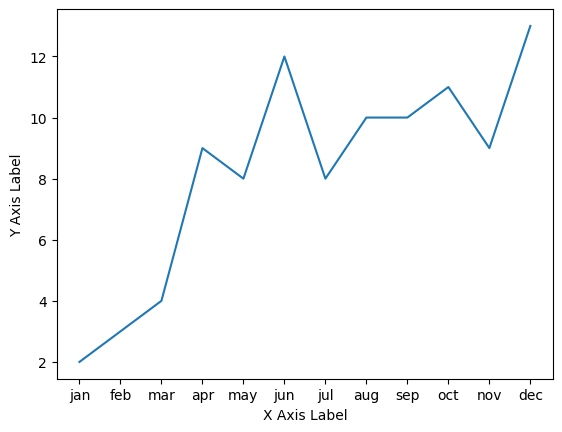

In [3]:
values = [2, 3, 4, 9, 8, 12, 8, 10, 10, 11, 9, 13]
labs = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

plt.ylabel('Y Axis Label')
plt.xlabel('X Axis Label')
plt.plot(labs, values)
plt.savefig('linePlot01.png')
plt.show()

In [4]:
ImageNumber = 11

In [7]:
#image = cv2.imread("C:/Users/DELL1/Pictures/basicPlot.png")
# image = cv2.imread("C:/Users/DELL1/Pictures/basicPlotBars.png")
#image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Bar/Master.jpg")
# image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Line/linePlot01.png")
image = cv2.imread(f'c:\\College\\Sem 08\\Major Project\\Graphs\\Line\\Testing\\testImages\\{ImageNumber}\\{ImageNumber}.png')

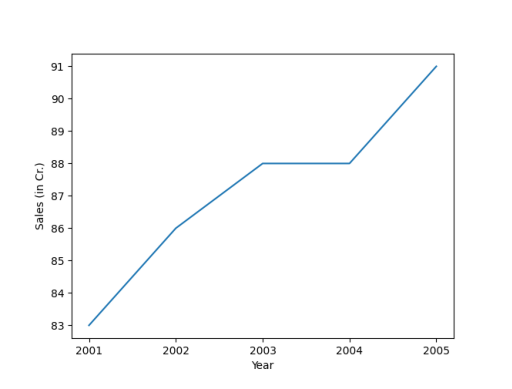

In [8]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [9]:
ab = 7
bc = 7

In [10]:
height, width, channels = image.shape
height_part = height//ab
width_part = width//bc

In [11]:
first_verti = image[:, :width_part]
last_hori = image[-height_part:, :]

In [12]:
cv2.imshow('First Vertical Strip', first_verti)
cv2.imshow('Last Horiontal Strip', last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [13]:
grey_first_verti = cv2.cvtColor(first_verti, cv2.COLOR_BGR2GRAY)
grey_last_hori = cv2.cvtColor(last_hori, cv2.COLOR_BGR2GRAY)

cv2.imshow('Grey Scale Strip Verti', grey_first_verti)
cv2.imshow('Grey Scale Strip Horiz', grey_last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

X-Axis

In [14]:
import keras_ocr

pipeline = keras_ocr.pipeline.Pipeline()

images = [keras_ocr.tools.read(last_hori)]

predictions = pipeline.recognize(images)

imageWithBoxKeras = last_hori.copy()

for prediction in predictions[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKeras, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKeras)
cv2.waitKey(0)
cv2.destroyAllWindows() 

Looking for C:\Users\DELL1\.keras-ocr\craft_mlt_25k.h5
Instructions for updating:
Use `tf.image.resize(...method=ResizeMethod.BILINEAR...)` instead.
Looking for C:\Users\DELL1\.keras-ocr\crnn_kurapan.h5
1/1 [==============================] - 3s 3s/step


In [15]:
import pandas as pd

def predictions_to_dataframe(predictions):
    data_for_df = []
    
    for prediction in predictions[0]:  
        text, box = prediction
        x_center = (box[:, 0].min() + box[:, 0].max()) / 2
        y_center = (box[:, 1].min() + box[:, 1].max()) / 2
        box_width = box[:, 0].max() - box[:, 0].min()
        box_height = box[:, 1].max() - box[:, 1].min()
        box = box
        data_for_df.append({
            'text': text,
            'x_center': x_center, 
            'y_center': y_center, 
            'box_height': box_height, 
            'box_width': box_width,
            'box': box
        })
    
    return pd.DataFrame(data_for_df)

In [16]:
df = predictions_to_dataframe(predictions)
df

,text,x_center,y_center,box_height,box_width,box
0,e,66.5,2.5,5.0,7.0,"[[63.0, 0.0], [70.0, 0.0], [70.0, 5.0], [63.0,..."
1,2001,102.5,31.5,13.0,35.0,"[[85.0, 25.0], [120.0, 25.0], [120.0, 38.0], [..."
2,2002,216.0,31.5,13.0,36.0,"[[198.0, 25.0], [234.0, 25.0], [234.0, 38.0], ..."
3,2003,329.0,31.5,13.0,36.0,"[[311.0, 25.0], [347.0, 25.0], [347.0, 38.0], ..."
4,2004,441.0,31.5,13.0,36.0,"[[423.0, 25.0], [459.0, 25.0], [459.0, 38.0], ..."
5,2005,554.0,31.5,13.0,36.0,"[[536.0, 25.0], [572.0, 25.0], [572.0, 38.0], ..."
6,year,329.0,50.0,12.0,30.0,"[[314.0, 44.0], [344.0, 44.0], [344.0, 56.0], ..."


X-Axis Label

In [17]:
yMax = df['y_center'].mode()[0]
yMax

31.5

In [18]:
x_label = df[(df['y_center'] >= (yMax - 5)) & (df['y_center'] <= (yMax + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_label

,text,x_center,y_center,box_height,box_width,box
0,2001,102.5,31.5,13.0,35.0,"[[85.0, 25.0], [120.0, 25.0], [120.0, 38.0], [..."
1,2002,216.0,31.5,13.0,36.0,"[[198.0, 25.0], [234.0, 25.0], [234.0, 38.0], ..."
2,2003,329.0,31.5,13.0,36.0,"[[311.0, 25.0], [347.0, 25.0], [347.0, 38.0], ..."
3,2004,441.0,31.5,13.0,36.0,"[[423.0, 25.0], [459.0, 25.0], [459.0, 38.0], ..."
4,2005,554.0,31.5,13.0,36.0,"[[536.0, 25.0], [572.0, 25.0], [572.0, 38.0], ..."


In [19]:
k = len(x_label)-1
l = k
dis = 0

for indx in x_label.index:
    if k > 0:
        dis += abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
        k -= 1
    else:
        break

In [20]:
avg_dis = dis/l
avg_dis

112.875

In [21]:
# x_labels = []
# xlabel = x_label['text'][0]

# for indx in x_label.index:
#     if l > 0:
#         kml = abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
#         if kml <= (avg_dis-5):
#             xlabel += x_label['text'][indx+1]
#             l -= 1
#         else:
#            x_labels.append(xlabel) 
#            xlabel = x_label['text'][indx+1]
#            l -= 1
           
# x_labels.append(xlabel)
# x_labels

In [22]:
x_labelsWithCent = []
xlabel = x_label['text'][0]
labCent = x_label['x_center'][0]
kmkmkmk = 1

for indx in x_label.index:
    if l > 0:
        kml = abs(x_label['x_center'][indx] - x_label['x_center'][indx+1])
        if kml <= (avg_dis-5):
            xlabel += x_label['text'][indx+1]
            labCent += x_label['x_center'][indx+1]
            kmkmkmk += 1
            l -= 1
        else:
           labCent = labCent/kmkmkmk
           x_labelsWithCent.append((xlabel, labCent)) 
           xlabel = x_label['text'][indx+1]
           labCent = x_label['x_center'][indx+1]
           kmkmkmk = 1
           l -= 1

labCent = labCent/kmkmkmk           
x_labelsWithCent.append((xlabel, labCent))
x_labelsWithCent

[('2001', 102.5),
 ('2002', 216.0),
 ('2003', 329.0),
 ('2004', 441.0),
 ('2005', 554.0)]

X-Axis Title

In [23]:
x_title = df[df['y_center'] > (yMax + 5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,year,329.0,50.0,12.0,30.0,"[[314.0, 44.0], [344.0, 44.0], [344.0, 56.0], ..."


In [24]:
yMax1 = x_title['y_center'].mode()[0]
yMax1

50.0

In [25]:
x_title = x_title[(x_title['y_center'] >= (yMax1 - 5)) & (x_title['y_center'] <= (yMax1 + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,year,329.0,50.0,12.0,30.0,"[[314.0, 44.0], [344.0, 44.0], [344.0, 56.0], ..."


In [26]:
xtitle = ''

for indx in x_title.index:
    xtitle += x_title['text'][indx] + ' '
        
xtitle = xtitle.strip()
xtitle

'year'

X-Axis Detection

In [27]:
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)

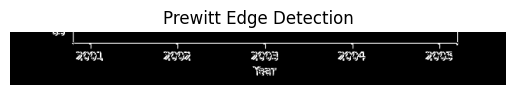

In [28]:
img_prewittx = cv2.filter2D(grey_last_hori, -1, kernelx)
img_prewitty = cv2.filter2D(grey_last_hori, -1, kernely)

img_prewitt = img_prewittx + img_prewitty

plt.imshow(img_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

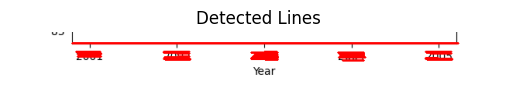

In [29]:
linesInLastHori = last_hori.copy()

_, binary_prewitt = cv2.threshold(img_prewitt, 50, 255, cv2.THRESH_BINARY)
linesP = cv2.HoughLinesP(binary_prewitt, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInLastHori, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
linesInLastHori = cv2.cvtColor(linesInLastHori, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

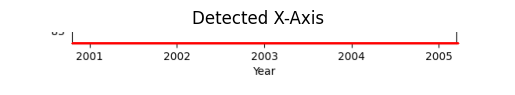

In [30]:
xAxisDetected = last_hori.copy()

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        if y1 < yMax and y2 < yMax:
            cv2.line(xAxisDetected, (x1, y1), (x2, y2), (0, 0, 255), 2)
            break
        
xAxisDetected = cv2.cvtColor(xAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(xAxisDetected )
plt.title('Detected X-Axis')
plt.axis('off')
plt.show()

In [31]:
xAxisCordsInStrip = [[x1, y1], [x2, y2]]
xAxisCordsInStrip = sorted(xAxisCordsInStrip, key=lambda x: x[0])
xAxisCordsInStrip

[[80, 14], [578, 14]]

In [32]:
original_height_part = height - height_part

xAxisCords = [[xAxisCordsInStrip[0][0], xAxisCordsInStrip[0][1] + original_height_part], [xAxisCordsInStrip[1][0], xAxisCordsInStrip[1][1] + original_height_part]]
xAxisCords

[[80, 426], [578, 426]]

In [33]:
xAxisCord = 0

for i in xAxisCords:
    xAxisCord+=i[1]
    
xAxisCord = xAxisCord/2
xAxisCord

426.0

In [34]:
x_label_copy = x_label.copy()

for index, row in x_label_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_label_copy.at[index, 'box'] = arr

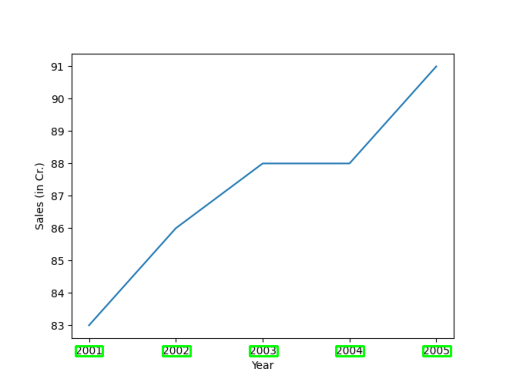

In [35]:
image11 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1223 = image11.copy()

for indx in x_label_copy.index:
    box = x_label_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [36]:
x_title_copy = x_title.copy()

for index, row in x_title_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_title_copy.at[index, 'box'] = arr

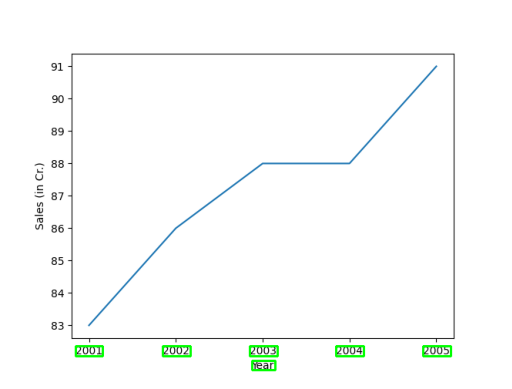

In [37]:
for indx in x_title_copy.index:
    box = x_title_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Y-Axis

In [38]:
images = [keras_ocr.tools.read(first_verti)]

predictions1 = pipeline.recognize(images)

imageWithBoxKerasVerti = first_verti.copy()

for prediction in predictions1[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasVerti, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasVerti)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


Y-Axis Labels

In [39]:
df1 = predictions_to_dataframe(predictions1)
df1

,text,x_center,y_center,box_height,box_width,box
0,91,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53..."
1,90,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ..."
2,89,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ..."
3,88,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ..."
4,g,39.0,211.0,26.0,14.0,"[[32.0, 198.0], [46.0, 198.0], [46.0, 224.0], ..."
5,s,38.5,236.5,21.0,13.0,"[[32.0, 226.0], [45.0, 226.0], [45.0, 247.0], ..."
6,87,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ..."
7,s,39.0,268.5,39.0,14.0,"[[32.0, 249.0], [46.0, 249.0], [46.0, 288.0], ..."
8,86,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ..."
9,85,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ..."


In [40]:
df11 = df1.copy()
df11 = df11[df11['text'].str.isdigit()]
df11['text'] = df11['text'].astype(float)
df11

,text,x_center,y_center,box_height,box_width,box
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53..."
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ..."
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ..."
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ..."
6,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ..."
8,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ..."
9,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ..."
10,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ..."
11,85.0,63.5,411.5,13.0,19.0,"[[54.0, 405.0], [73.0, 405.0], [73.0, 418.0], ..."


In [41]:
xMax = df11['x_center'].mode()[0]
xMax

63.5

In [42]:
y_label = df11[(df11['x_center'] >= (xMax - 5)) & (df11['x_center'] <= (xMax + 5))].sort_values(by='y_center', ascending=True).reset_index(drop=True)
y_label

,text,x_center,y_center,box_height,box_width,box
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53..."
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ..."
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ..."
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ..."
4,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ..."
5,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ..."
6,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ..."
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ..."
8,85.0,63.5,411.5,13.0,19.0,"[[54.0, 405.0], [73.0, 405.0], [73.0, 418.0], ..."


In [43]:
y_label['diff'] = (y_label['text'].diff(periods=-1).abs())
y_label['pdiff'] = (y_label['y_center'].diff(periods=-1).abs())
y_label['vpp'] = (y_label['text'].diff(periods=-1).abs())/y_label['y_center'].diff(periods=-1).abs()
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53...",1.0,42.0,0.02381
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ...",1.0,42.0,0.02381
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ...",1.0,42.0,0.02381
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ...",1.0,42.0,0.02381
4,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ...",1.0,42.0,0.02381
5,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ...",1.0,42.0,0.02381
6,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ...",1.0,42.0,0.02381
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ...",1.0,42.0,0.02381
8,85.0,63.5,411.5,13.0,19.0,"[[54.0, 405.0], [73.0, 405.0], [73.0, 418.0], ...",NaN,NaN,NaN


In [44]:
most_common_diff = y_label['diff'][:-1].mode()[0]
most_common_diff

1.0

In [45]:
y_label['roundedVPP'] = y_label['vpp'].round(2)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53...",1.0,42.0,0.02381,0.02
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ...",1.0,42.0,0.02381,0.02
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ...",1.0,42.0,0.02381,0.02
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ...",1.0,42.0,0.02381,0.02
4,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ...",1.0,42.0,0.02381,0.02
5,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ...",1.0,42.0,0.02381,0.02
6,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ...",1.0,42.0,0.02381,0.02
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ...",1.0,42.0,0.02381,0.02
8,85.0,63.5,411.5,13.0,19.0,"[[54.0, 405.0], [73.0, 405.0], [73.0, 418.0], ...",NaN,NaN,NaN,NaN


In [46]:
mostCommonValue = y_label['roundedVPP'].value_counts().idxmax()
mostCommonIndex = y_label[y_label['roundedVPP'] == mostCommonValue].index[0]
mostCommonIndex

0

In [47]:
most_common_vpp = y_label['vpp'].iloc[mostCommonIndex]
# most_common_vpp = y_label['vpp'][:-1].mode()[0]

# if most_common_vpp == 0:
#     frequency = y_label['vpp'].value_counts()
#     print(frequency)
#     if len(frequency) > 1:
#         most_common_vpp = frequency.index[1] 

most_common_vpp

0.023809523809523808

In [48]:
inRange = y_label['vpp'].between(most_common_vpp - 0.05, most_common_vpp + 0.05)

y_label = y_label[ inRange | (y_label.index == y_label.index[-1])]
# y_label = y_label.drop(columns=['diff'])

y_label.reset_index(drop=True, inplace=True)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53...",1.0,42.0,0.02381,0.02
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ...",1.0,42.0,0.02381,0.02
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ...",1.0,42.0,0.02381,0.02
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ...",1.0,42.0,0.02381,0.02
4,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ...",1.0,42.0,0.02381,0.02
5,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ...",1.0,42.0,0.02381,0.02
6,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ...",1.0,42.0,0.02381,0.02
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ...",1.0,42.0,0.02381,0.02
8,85.0,63.5,411.5,13.0,19.0,"[[54.0, 405.0], [73.0, 405.0], [73.0, 418.0], ...",NaN,NaN,NaN,NaN


In [49]:
# y_label = y_label[(y_label['diff'] == most_common_diff)]
# y_label

In [50]:
# y_label = y_label.reset_index(drop=True)
# y_label

In [51]:
indexToDrop  = []
iii = 0
jjj = 1

if (y_label['diff'].iloc[0] != most_common_diff) or (most_common_vpp - 0.005 <= y_label['diff'].iloc[0] <= most_common_vpp + 0.005):
    indexToDrop.append(0)
    iii = jjj
    jjj += 1

In [52]:
while jjj != (len(y_label)):
    kkk = y_label['text'][iii] - y_label['text'][jjj]
    
    if kkk > 0:
       iii = jjj
       jjj += 1
    else:
        indexToDrop.append(jjj)
        jjj+=1
    
indexToDrop

[8]

In [53]:
for i in range(len(y_label)):
    if i in indexToDrop:
        y_label.drop(index=i, inplace=True)
        
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,91.0,62.0,75.5,13.0,18.0,"[[53.0, 69.0], [71.0, 69.0], [71.0, 82.0], [53...",1.0,42.0,0.02381,0.02
1,90.0,64.0,117.5,13.0,18.0,"[[55.0, 111.0], [73.0, 111.0], [73.0, 124.0], ...",1.0,42.0,0.02381,0.02
2,89.0,63.5,159.5,13.0,19.0,"[[54.0, 153.0], [73.0, 153.0], [73.0, 166.0], ...",1.0,42.0,0.02381,0.02
3,88.0,63.5,201.5,13.0,19.0,"[[54.0, 195.0], [73.0, 195.0], [73.0, 208.0], ...",1.0,42.0,0.02381,0.02
4,87.0,63.5,243.5,13.0,19.0,"[[54.0, 237.0], [73.0, 237.0], [73.0, 250.0], ...",1.0,42.0,0.02381,0.02
5,86.0,63.0,285.5,13.0,20.0,"[[53.0, 279.0], [73.0, 279.0], [73.0, 292.0], ...",1.0,42.0,0.02381,0.02
6,85.0,63.5,327.5,13.0,19.0,"[[54.0, 321.0], [73.0, 321.0], [73.0, 334.0], ...",1.0,42.0,0.02381,0.02
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ...",1.0,42.0,0.02381,0.02


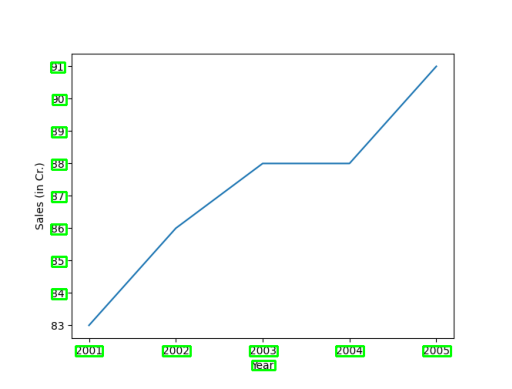

In [54]:
for indx in y_label.index:
    box = y_label['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Chceck for Equal Pixel Distribution

In [55]:
if len(y_label) == 1:
    most_common_pdiff = y_label['pdiff'][:].mode()[0]
else:
    most_common_pdiff = y_label['pdiff'][:-1].mode()[0]
most_common_pdiff

42.0

In [56]:
y_label[-1:]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
7,84.0,63.5,369.5,13.0,19.0,"[[54.0, 363.0], [73.0, 363.0], [73.0, 376.0], ...",1.0,42.0,0.02381,0.02


In [57]:
corVal = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

print(betweenFirst)

56.5


In [58]:
import math

corVal = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

if corVal == most_common_diff:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        # Case-1
        print("Case-1")
        toAdd = 0
        fromCal = xAxisCord
    else:
        # Case-5
        print("Case-5")
        toAdd = corVal
        fromCal = corFir
else:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        #Case-3
        print("Case-3")
        toAdd = corVal - most_common_diff
        fromCal = xAxisCord
    elif (betweenFirst < most_common_pdiff - 5):
        #Case-7
        print("Case-7")
        toAdd = corVal
        fromCal = corFir
    else:
        dif = betweenFirst/most_common_pdiff
        
        if dif - math.floor(dif) > 0.9:
            dif = math.ceil(dif)
        else:
            dif = math.floor(dif)
            
        # newCorVal = corVal - dif*most_common_diff
        # newCorFir = corFir - dif*most_common_pdiff
        fin = abs(betweenFirst - dif*most_common_pdiff)
        
        if fin < 5:
            newCorVal = corVal - (dif-1)*most_common_diff
            # newCorFir = corFir - (dif-1)*most_common_pdiff
            
            if newCorVal == most_common_diff:
                #Case-2
                print("Case-2")
                toAdd = 0
                fromCal = xAxisCord
            else:
                #Case-4
                print("Case-4")
                toAdd = corVal - (dif)*most_common_diff
                fromCal = xAxisCord
        else:
            newCorVal = corVal - (dif)*most_common_diff
            
            # if newCorVal == most_common_diff:
            
            #Case-6&8
            print("Case-6&8")
            toAdd = newCorVal
            fromCal = xAxisCord-fin
            
            # else:
            #     #Case-8
            #     toAdd = corVal - (dif)*most_common_diff
            #     fromCal = xAxisCord

Case-6&8


In [59]:
# import math

# corVal = y_label['text'].iloc[-1]
# corFir = y_label['y_center'].iloc[-1]
# betweenFirst = xAxisCord - corFir

# if corVal == most_common_diff:
#     if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
#         # Case-1
#         toAdd = 0
#         fromCal = xAxisCord
#     else:
#         # Case-5
#         toAdd = corVal
#         fromCal = corFir
# else:
#     if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
#         #Case-3
#         toAdd = corVal - most_common_diff
#         fromCal = xAxisCord
#     elif (betweenFirst < most_common_pdiff - 5):
#         #Case-7
#         toAdd = corVal
#         fromCal = corFir
#     else:   
#         dif = betweenFirst/most_common_pdiff

#         if dif - math.floor(dif) > 0.9:
#             dif = math.ceil(dif)
#         else:
#             dif = math.floor(dif)

#         if dif == 1:
#             newCorVal = corVal - most_common_diff
#             newCorFir = corFir - most_common_pdiff
#             newBetweenFirst = xAxisCord - newCorFir
#         else:   
#             newCorVal = corVal - (dif-1)*most_common_diff
#             newCorFir = corFir - (dif-1)*most_common_pdiff
#             newBetweenFirst = xAxisCord - newCorFir


#         if newCorVal == most_common_diff:
#             if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
#                 # Case-2
#                 toAdd = 0
#                 fromCal = xAxisCord
#             else:
#                 # Case-6
#                 toAdd = newCorVal
#                 fromCal = newCorFir
#         else:
#             if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
#                 # Case-4
#                 toAdd = newCorVal - most_common_diff
#                 fromCal = xAxisCord
#             else:
#                 # Case-8
#                 toAdd = newCorVal
#                 fromCal = newCorFir

In [60]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         if y_label['text'].iloc[-1] == most_common_diff:
#             toAdd = 0
#             fromCal = xAxisCord
#         else:
#             toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#             fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

In [61]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         toAdd = 0
#         fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

In [62]:
fromCal

411.5

Value Per Pixel

In [63]:
y_label['vpp'][:-1].mean()

0.023809523809523808

In [64]:
# vpp = 0
# tot = len(y_label)-1

# for i in range (tot):
#     vpp += abs(y_label['text'][i+1] - y_label['text'][i])/abs(y_label['y_center'][i+1] - y_label['y_center'][i])
    
# vpp = vpp/tot
# vpp

In [65]:
if len(y_label) == 1:   
    vpp = y_label['vpp'][:].mean()
else:
    vpp = y_label['vpp'][:-1].mean()
vpp

0.023809523809523808

Y-Axis Title

In [66]:
rotated_image = cv2.rotate(first_verti, cv2.ROTATE_90_CLOCKWISE)
rotated_image1 = cv2.rotate(first_verti, cv2.ROTATE_90_COUNTERCLOCKWISE)

cv2.imshow('90 CLOCKWISE', rotated_image)
cv2.imshow('90 COUNTERCLOCKWISE', rotated_image1)
cv2.waitKey(0)
cv2.destroyAllWindows() 

In [67]:
images = [keras_ocr.tools.read(rotated_image)]

predictions2 = pipeline.recognize(images)

imageWithBoxKerasRotateColck = rotated_image.copy()

for prediction in predictions2[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasRotateColck, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasRotateColck)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


In [68]:
df2 = predictions_to_dataframe(predictions2)
df2

,text,x_center,y_center,box_height,box_width,box
0,sales,212.0,39.0,14.0,38.0,"[[193.0, 32.0], [231.0, 32.0], [231.0, 46.0], ..."
1,in,243.5,39.0,14.0,21.0,"[[233.0, 32.0], [254.0, 32.0], [254.0, 46.0], ..."
2,cry,269.0,39.5,13.0,26.0,"[[256.0, 33.0], [282.0, 33.0], [282.0, 46.0], ..."
3,oo,69.0,59.0,10.0,12.0,"[[63.0, 54.0], [75.0, 54.0], [75.0, 64.0], [63..."
4,oo,111.0,59.0,10.0,12.0,"[[105.0, 54.0], [117.0, 54.0], [117.0, 64.0], ..."
5,o,153.5,63.0,18.0,13.0,"[[147.0, 54.0], [160.0, 54.0], [160.0, 72.0], ..."
6,g,237.5,62.5,17.0,13.0,"[[231.0, 54.0], [244.0, 54.0], [244.0, 71.0], ..."
7,oo,279.0,58.5,9.0,12.0,"[[273.0, 54.0], [285.0, 54.0], [285.0, 63.0], ..."
8,oo,320.5,58.5,9.0,11.0,"[[315.0, 54.0], [326.0, 54.0], [326.0, 63.0], ..."
9,d,405.5,62.5,17.0,13.0,"[[399.0, 54.0], [412.0, 54.0], [412.0, 71.0], ..."


In [69]:
df2 = df2[df2['y_center'] < (xMax-5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
df2

,text,x_center,y_center,box_height,box_width,box
0,sales,212.0,39.0,14.0,38.0,"[[193.0, 32.0], [231.0, 32.0], [231.0, 46.0], ..."
1,in,243.5,39.0,14.0,21.0,"[[233.0, 32.0], [254.0, 32.0], [254.0, 46.0], ..."
2,cry,269.0,39.5,13.0,26.0,"[[256.0, 33.0], [282.0, 33.0], [282.0, 46.0], ..."


In [70]:
ytitle = ''

for indx in df2.index:
    ytitle += df2['text'][indx] + ' '
        
ytitle = ytitle.strip()
ytitle

'sales in cry'

In [71]:
blahblah = [4, 5, 7]

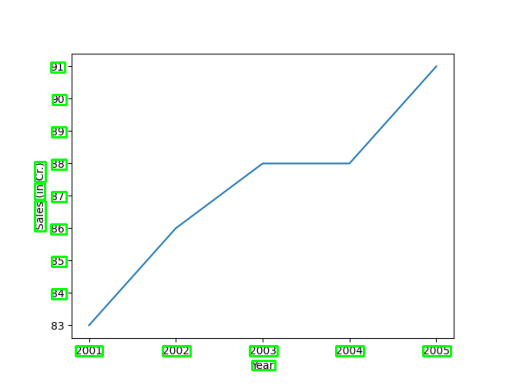

In [72]:
for indx in df1.index:
    if indx in blahblah:
        box = df1['box'][indx]
        box = box.astype(int)
        cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show() 

Y-Axis Detection

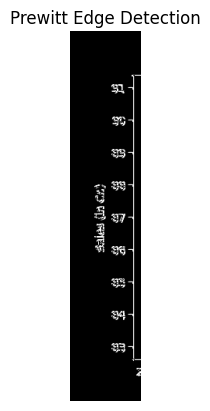

In [73]:
img_prewittx1 = cv2.filter2D(grey_first_verti, -1, kernelx)
img_prewitty1 = cv2.filter2D(grey_first_verti, -1, kernely)

img_prewitt1 = img_prewittx1 + img_prewitty1

plt.imshow(img_prewitt1, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

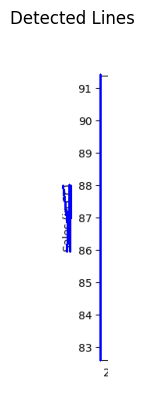

In [74]:
linesInFirstVeti = first_verti.copy()

_, binary_prewitt1 = cv2.threshold(img_prewitt1, 50, 255, cv2.THRESH_BINARY)
linesP1 = cv2.HoughLinesP(binary_prewitt1, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInFirstVeti, (x1, y1), (x2, y2), (255, 0, 0), 2)
        print()
    
linesInLastHori = cv2.cvtColor(linesInFirstVeti, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

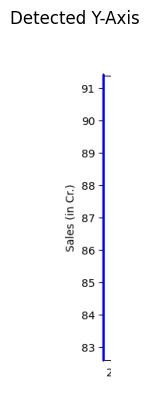

In [75]:
yAxisDetected = first_verti.copy()

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        if x1 > xMax and x2 > xMax:
            cv2.line(yAxisDetected, (x1, y1), (x2, y2), (255, 0, 0), 2)
            break
        
yAxisDetected = cv2.cvtColor(yAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(yAxisDetected )
plt.title('Detected Y-Axis')
plt.axis('off')
plt.show()

In [76]:
yAxisCords = [[x1, y1], [x2, y2]]
yAxisCords = sorted(yAxisCords, key=lambda x: x[1])
yAxisCords

[[81, 56], [81, 427]]

In [77]:
yAxisCord = 0

for i in yAxisCords:
    yAxisCord+=i[0]
    
yAxisCord = yAxisCord/2
yAxisCord

81.0

Detcted Both Axes 

In [78]:
detectedAxes = image.copy()

cv2.line(detectedAxes, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (0, 0, 255), 2)
cv2.line(detectedAxes, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (0, 255, 0), 2)

cv2.imshow('Image with Both Axes', detectedAxes)
cv2.waitKey(0)
cv2.destroyAllWindows()

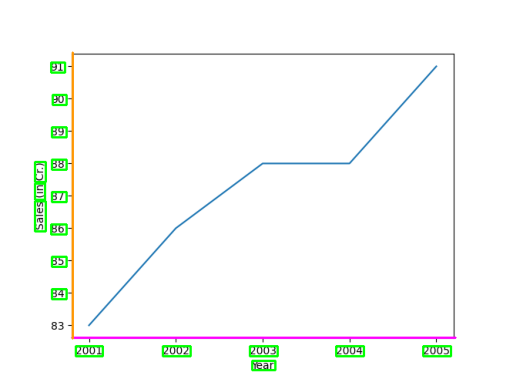

In [79]:
cv2.line(image1223, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (255, 0, 255), 2)
cv2.line(image1223, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (255, 150, ), 2)

plt.imshow(image1223)
plt.axis('off')
plt.show()

Color Detction

Croping Image

In [80]:
yAxisCords

[[81, 56], [81, 427]]

In [81]:
xAxisCords

[[80, 426], [578, 426]]

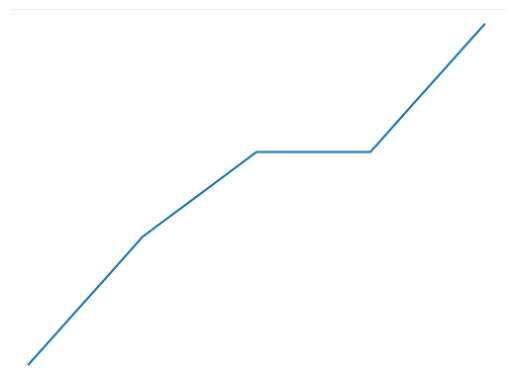

In [82]:
fropTop = yAxisCords[0][1]+3
toBottom = xAxisCords[0][1]-3

fromLeft = (yAxisCords[0][0] + yAxisCords[1][0])//2+3
toRight = xAxisCords[1][0]-3

imagePart = image[fropTop:toBottom, fromLeft:toRight]

plt.imshow(cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
# cv2.imshow('part', imagePart)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [83]:
toRight

575

Color Detection

In [84]:
imagePart1 = cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB)

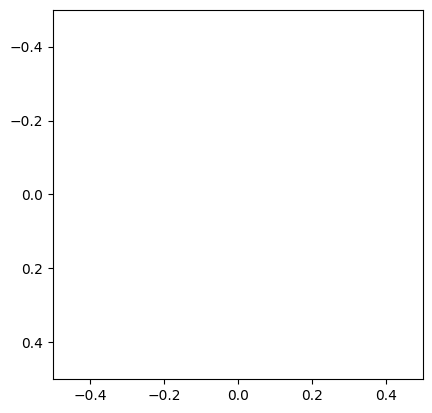

[255.55382 255.56651 255.5755 ]


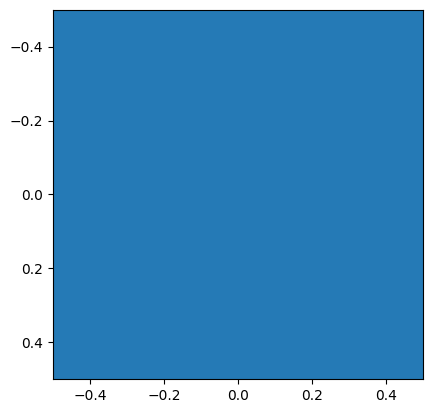

[ 37.502937 122.875435 182.07167 ]


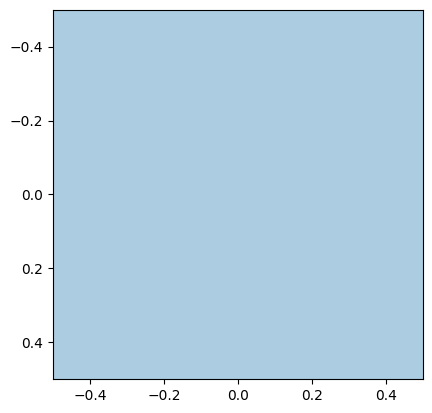

[172.04337 204.40816 226.83673]


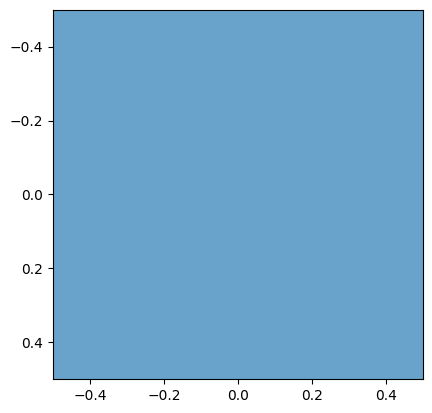

[105.26775 163.7705  204.39616]


In [85]:
pixels = imagePart1.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 4

_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

unique, counts = np.unique(labels, return_counts=True)

sorted_colors = sorted(zip(counts, centers), key=lambda x: x[0], reverse=True)

sorted_colors = [tpl[1] for tpl in sorted_colors]

for color in sorted_colors:
    plt.imshow([[color.astype(np.uint8)/255]])
    plt.show()
    print(color)

In [86]:
modified_image = np.copy(imagePart1)

cluster_2nd_coords = []

# Assign white color to pixels belonging to the 2nd cluster and black color to pixels belonging to other clusters
for idx, color in enumerate(centers):
    mask = (labels == idx).reshape(imagePart1.shape[:2])
    # coords = np.column_stack(np.where(mask))
    
    if (idx == 1) or (idx == 2):
        modified_image[mask] = [0, 0, 0] 
        # cluster_2nd_coords.extend(coords.tolist())
    else:
        modified_image[mask] = [255, 255, 255]
        
cv2.imshow('Original Image', cv2.cvtColor(imagePart1, cv2.COLOR_BGR2RGB))
cv2.imshow('Modified Image', modified_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [87]:
cluster_2nd_coords

[]

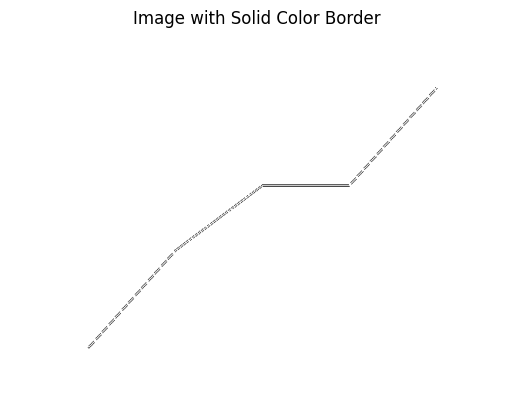

In [88]:
border_color = [255, 255, 255]

image_with_border = cv2.copyMakeBorder(modified_image, fropTop, (height - toBottom), fromLeft, (width - toRight), cv2.BORDER_CONSTANT, value=border_color)

plt.imshow(cv2.cvtColor(image_with_border, cv2.COLOR_BGR2RGB))
plt.title("Image with Solid Color Border")
plt.axis('off')
plt.show()

In [89]:
# for i in cluster_2nd_coords:
#     i[0] += fropTop
#     i[1] += fromLeft

# cluster_2nd_coords

Line Detection

In [90]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [91]:
gray_Line = cv2.cvtColor(image_with_border, cv2.COLOR_BGR2GRAY)

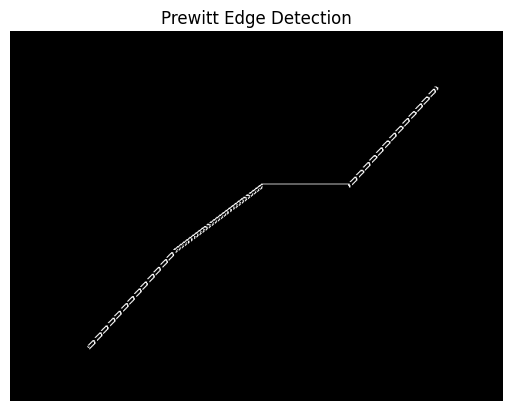

In [92]:
img_prewittx2 = cv2.filter2D(gray_Line, -1, kernelx)
img_prewitty2 = cv2.filter2D(gray_Line, -1, kernely)

img_prewitt2 = img_prewittx2 + img_prewitty2

plt.imshow(img_prewitt2, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

In [93]:
abcImge = image_with_border.copy()

edges = cv2.Canny(img_prewitt2, 50, 150, apertureSize=3)

lines = cv2.HoughLines(edges, 1, np.pi/180, 200)  


if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(abcImge, (x1, y1), (x2, y2), (0, 0, 255), 2)
        
# Show the result
cv2.imshow('Detected Lines', abcImge)
cv2.waitKey(0)
cv2.destroyAllWindows()

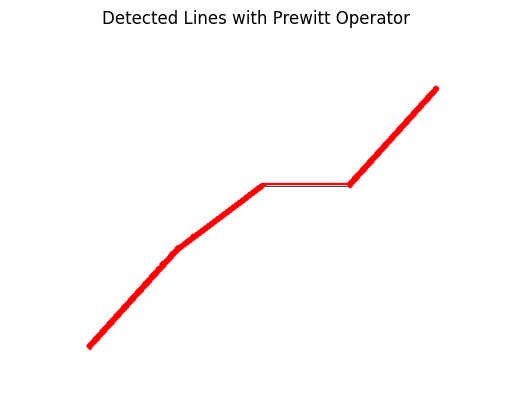

In [94]:
prewittlines2 = image_with_border.copy()

linesP = cv2.HoughLinesP(img_prewitt2, 1, np.pi/180, 20, minLineLength=20, maxLineGap=10)

horizontal_lines = []

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        angle = np.arctan2(y2 - y1, x2 - x1) * 180.0 / np.pi
        
        # if (x1 > yAxisCord and x2 > yAxisCord) and (y1 < xAxisCord and y2 < xAxisCord):
        #     if abs(angle) < 3 or abs(angle) > 177:
        cv2.line(prewittlines2, (x1, y1), (x2, y2), (0, 0, 255), 2)
        horizontal_lines.append([x1, y1, x2, y2]) 
                
prewittlines2 = cv2.cvtColor(prewittlines2, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines2)
plt.title('Detected Lines with Prewitt Operator')
plt.axis('off')
plt.show()

In [95]:
def merge_close_lines(lines, delta):
    if not lines:
        return []

    lines_sorted = sorted(lines, key=lambda line: line[0])
    
    merged_lines = []
    temp_line_group = [lines_sorted[0]]

    for current_line in lines_sorted[1:]:
        last_line_in_group = temp_line_group[-1]
        if abs(current_line[0] - last_line_in_group[0]) <= delta or abs(current_line[2] - last_line_in_group[2]) <= delta:
            temp_line_group.append(current_line)
        else:
            avg_line = np.mean(temp_line_group, axis=0).astype(int)
            merged_lines.append(avg_line)
            temp_line_group = [current_line]

    if temp_line_group:
        avg_line = np.mean(temp_line_group, axis=0).astype(int)
        merged_lines.append(avg_line)

    return merged_lines

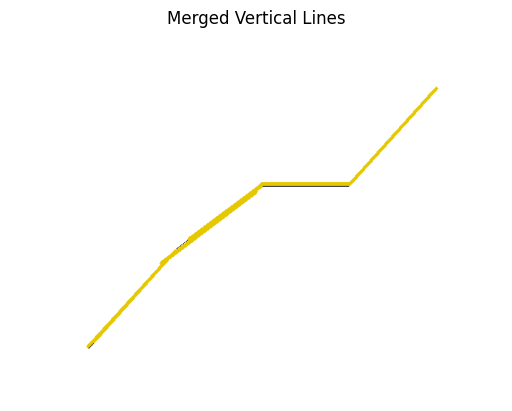

In [96]:
prewittlines3 = image_with_border.copy()

merged_lines = merge_close_lines(horizontal_lines, 3)
l=0
for line in merged_lines:
    l+=1
    x1, y1, x2, y2 = line
    cv2.line(prewittlines3, (x1, y1), (x2, y2), (0, 200, 230), 3)

prewittlines3 = cv2.cvtColor(prewittlines3, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines3)
plt.title('Merged Vertical Lines')
plt.axis('off')
plt.show()

In [97]:
l

6

In [98]:
def find_intersection(line1_start, line1_end, line2_start, line2_end):
    x1, y1 = line1_start
    x2, y2 = line1_end
    
    x3, y3 = line2_start
    x4, y4 = line2_end
    
    # Calculate coefficients for the equations of the lines
    a1 = y2 - y1
    b1 = x1 - x2
    c1 = a1 * x1 + b1 * y1
    
    a2 = y4 - y3
    b2 = x3 - x4
    c2 = a2 * x3 + b2 * y3
    
    # Calculate determinant
    determinant = a1 * b2 - a2 * b1
    
    if determinant == 0:
        # Lines are parallel, so no intersection
        return None
    
    # Calculate intersection point
    x_intersect = (b2 * c1 - b1 * c2) / determinant
    y_intersect = (a1 * c2 - a2 * c1) / determinant
    
    return (x_intersect, y_intersect)

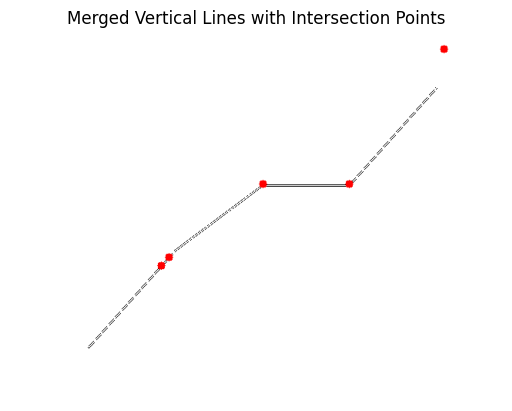

In [99]:
prewittlines4 = image_with_border.copy()

intersection_points = []

for i in range(len(merged_lines) - 1):
    line1 = merged_lines[i]
    line2 = merged_lines[i + 1]
    
    intersection_point = find_intersection((line1[0], line1[1]), (line1[2], line1[3]), 
                                           (line2[0], line2[1]), (line2[2], line2[3]))
    if intersection_point:
        intersection_points.append(intersection_point)

for point in intersection_points:
    x, y = point
    cv2.circle(prewittlines4, (int(x), int(y)), 5, (255, 0, 0), -1)

# Display the image with intersection points
plt.imshow(prewittlines4)
plt.title('Merged Vertical Lines with Intersection Points')
plt.axis('off')
plt.show()

In [100]:
def overlay_images(background_img, overlay_img):
    combined_image = cv2.addWeighted(background_img, 0.5, overlay_img, 0.5, 0)
    return combined_image

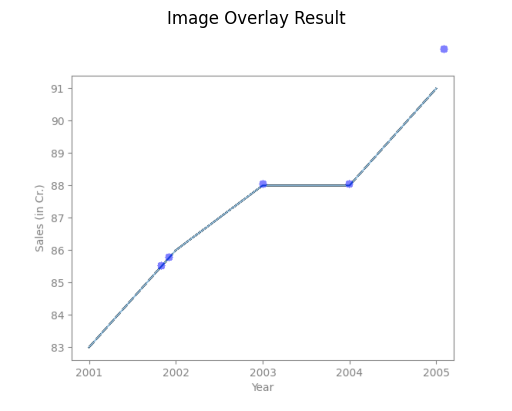

In [101]:
combined_image = overlay_images(image, prewittlines4)

# Display the result
plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
plt.title("Image Overlay Result")
plt.axis('off')
plt.show()

Sol 01

In [102]:
def merge_close_points(points, threshold):
    if not points:
        return []

    # Sort points based on x, then y (to make sure points are sequentially checked in a logical order)
    points.sort(key=lambda x: (x[0], x[1]))
    merged_points = [points[0]]

    for current in points[1:]:
        last = merged_points[-1]
        if np.sqrt((current[0] - last[0])**2 + (current[1] - last[1])**2) <= threshold:
            # Merge points by averaging their coordinates
            merged_point = ((current[0] + last[0]) / 2, (current[1] + last[1]) / 2)
            merged_points[-1] = merged_point  # Update the last point in the list
        else:
            merged_points.append(current)

    return merged_points

In [103]:
x_coords = x_label['x_center'].values
differences = np.diff(x_coords)

average_difference = np.mean(differences)
average_difference

112.875

In [104]:
intersection_points01 = []

line1 = merged_lines[0]
intersection_points01.append((line1[0], line1[1]))

for i in range(len(merged_lines) - 1):
    line1 = merged_lines[i]
    line2 = merged_lines[i + 1]
    
    if abs(line1[0] - line2[0]) < average_difference + 1:
        intersection_point = find_intersection((line1[0], line1[1]), (line1[2], line1[3]), 
                                           (line2[0], line2[1]), (line2[2], line2[3]))
        if intersection_point:
            intersection_points01.append(intersection_point)
    else:
        intersection_points01.append((line1[2], line1[3]))
        intersection_points01.append((line2[0], line2[1]))
        
line1 = merged_lines[-1]
intersection_points01.append((line1[2], line1[3]))

merged_intersection_points = merge_close_points(intersection_points01, threshold=5)

In [105]:
merged_intersection_points

[(101, 409),
 (196.6153846153846, 304.0769230769231),
 (206.4126984126984, 293.12698412698415),
 (328.6857142857143, 198.0),
 (440.0, 198.5),
 (553, 74),
 (563.1363636363636, 23.40909090909091)]

In [106]:
merged_intersection_points = [coord for coord in merged_intersection_points if coord[0] >= 0 and coord[1] >= 0]
merged_intersection_points

[(101, 409),
 (196.6153846153846, 304.0769230769231),
 (206.4126984126984, 293.12698412698415),
 (328.6857142857143, 198.0),
 (440.0, 198.5),
 (553, 74),
 (563.1363636363636, 23.40909090909091)]

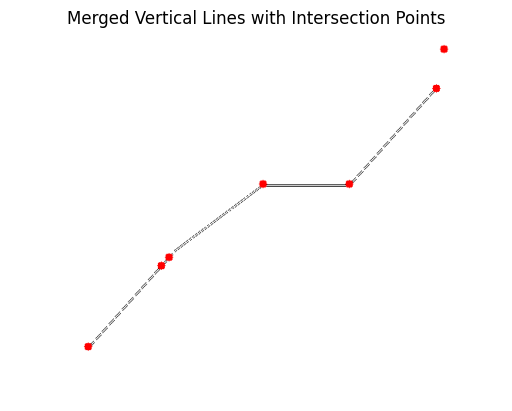

In [107]:
prewittlines43333 = image_with_border.copy()

for point in merged_intersection_points:
    x, y = point
    cv2.circle(prewittlines43333, (int(x), int(y)), 5, (255, 0, 0), -1)

# Display the image with intersection points
plt.imshow(prewittlines43333)
plt.title('Merged Vertical Lines with Intersection Points')
plt.axis('off')
plt.show()

In [108]:
merged_intersection_points

[(101, 409),
 (196.6153846153846, 304.0769230769231),
 (206.4126984126984, 293.12698412698415),
 (328.6857142857143, 198.0),
 (440.0, 198.5),
 (553, 74),
 (563.1363636363636, 23.40909090909091)]

In [109]:
len(merged_intersection_points)

7

In [110]:
# def is_within_radius(point_list, P, radius):
#     x_p, y_p = P  # Unpack the coordinates of point P
#     for x, y in point_list:
#         # Calculate Euclidean distance from P to each point in the list
#         distance = ((x - x_p) ** 2 + (y - y_p) ** 2) ** 0.5
#         if distance <= radius:
#             return True  # Return True as soon as a point within the radius is found
#     return False  # Return False if no points are within the radius

In [111]:
# final_points = []

# for point in merged_intersection_points:
#     xCord, yCord = point
#     point = [int(yCord), int(xCord)]
    
#     if is_within_radius(cluster_2nd_coords, point, 10):
#         yyyyy, xxxxx = point
#         final_points.append([xxxxx, yyyyy])

In [112]:
# final_points

In [113]:
# final_points = []

# for point in merged_intersection_points:
#     xCord, yCord = point
#     print(point)
#     point = [int(yCord), int(xCord)]
    
#     if point in cluster_2nd_coords:
#         # print(point)
#         yyyyy, xxxxx = point
#         final_points.append([xxxxx, yyyyy])
#         continue
#     else:
#         for i in range(1, 6):
#             point1 = [int(yCord), int(xCord) + i]
#             point2 = [int(yCord), int(xCord) - i]
#             point3 = [int(yCord) + i, int(xCord)]
#             point4 = [int(yCord) - i, int(xCord)]
#             point5 = [int(yCord) + i, int(xCord) + i]
#             point6 = [int(yCord) + i, int(xCord) - i]
#             point7 = [int(yCord) - i, int(xCord) + i]
#             point8 = [int(yCord) - i, int(xCord) - i]
            
#             if point1 in cluster_2nd_coords:
#                 # print(point1)
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point2 in cluster_2nd_coords:
#                 # print(point2)
#                 yyyyy, xxxxx = point2
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point3 in cluster_2nd_coords:
#                 # print(point3)
#                 yyyyy, xxxxx = point3
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point4 in cluster_2nd_coords:
#                 # print(point4)
#                 yyyyy, xxxxx = point4
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point5 in cluster_2nd_coords:
#                 # print(point5)
#                 yyyyy, xxxxx = point5
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point6 in cluster_2nd_coords:
#                 # print(point6)
#                 yyyyy, xxxxx = point6
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point7 in cluster_2nd_coords:
#                 # print(point7)
#                 yyyyy, xxxxx = point7
#                 final_points.append([xxxxx, yyyyy])
#                 break
#             if point8 in cluster_2nd_coords:
#                 # print(point8)
#                 yyyyy, xxxxx = point8
#                 final_points.append([xxxxx, yyyyy])
#                 break

In [114]:
# len(final_points)

In [115]:
merged_intersection_points.sort(key=lambda x: x[0])
merged_intersection_points

[(101, 409),
 (196.6153846153846, 304.0769230769231),
 (206.4126984126984, 293.12698412698415),
 (328.6857142857143, 198.0),
 (440.0, 198.5),
 (553, 74),
 (563.1363636363636, 23.40909090909091)]

In [116]:
def find_x_coordinate(x1, y1, x2, y2, x3):
    # Calculate the slope (m)
    m = (y2 - y1) / (x2 - x1)
    
    # Calculate the y-intercept (b)
    b = y1 - (m * x1)
    
    # Calculate x3 for given y3
    y3 = (m * x3) + b
    
    return y3

In [117]:
len(merged_intersection_points)

7

In [118]:
merged_intersection_points

[(101, 409),
 (196.6153846153846, 304.0769230769231),
 (206.4126984126984, 293.12698412698415),
 (328.6857142857143, 198.0),
 (440.0, 198.5),
 (553, 74),
 (563.1363636363636, 23.40909090909091)]

In [119]:
average_difference

112.875

In [120]:
added_points = []

for i in range(len(merged_intersection_points)-1):
    k = (merged_intersection_points[i+1][0] - merged_intersection_points[i][0])
    
    if (average_difference - 5) <= k <= (average_difference + 5):
        continue
    else:
        l = k/average_difference
        if (isinstance(l, int) and l >= 2) or (((l - math.floor(l)) < 0.2) and math.ceil(l) >= 2) or (((math.ceil(l) - l) < 0.2) and math.ceil(l)>=2):
            x1, y1 = merged_intersection_points[i]
            x2, y2 = merged_intersection_points[i+1]
            if (math.ceil(l) - l) < 0.2:
                l = math.ceil(l)
            elif (l - math.floor(l)) < 0.2:
                l = math.floor(l)
            
            for j in range(0, l-1):
                x3 = (j+1)*average_difference + merged_intersection_points[i][0]
                y3 = find_x_coordinate(x1, y1, x2, y2, x3)
                added_points.append([x3, y3])
        # else:
        #     if (isinstance(l, int) and l >= 2) or (((l - math.floor(l)) < 0.1) and l >= 2) or (((math.ceil(l) - l) < 0.1) and l>=2):
        #         x1, y1 = merged_intersection_points[i]
        #         x2, y2 = merged_intersection_points[i+1]

        #         if (math.ceil(l) - l) < 0.1:
        #             l = math.ceil(l)
        #         elif (l - math.floor(l)) < 0.1:
        #             l = math.floor(l)

        #         for j in range(0, l-1):
        #             x3 = merged_intersection_points[i][0] - (j+1)*average_difference
        #             y3 = merged_intersection_points(x1, y1, x2, y2, x3)
        #             merged_intersection_points.append([x3, y3])
added_points

[]

In [121]:
if added_points != []:
    final_points = []
    
    for i in merged_intersection_points:
        final_points.append(i)
    for i in added_points:
        final_points.append(i)
else:
    final_points = merged_intersection_points


In [122]:
len(final_points)

7

<function matplotlib.pyplot.show(close=None, block=None)>

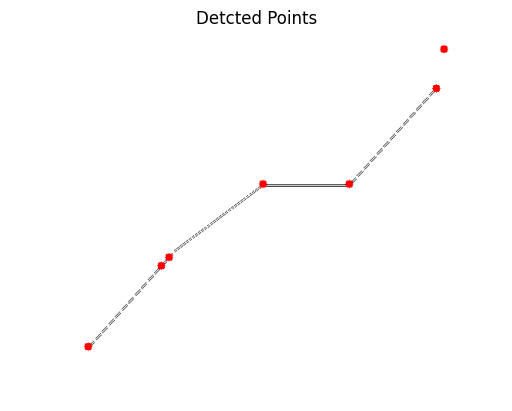

In [123]:
prewittlines45 = image_with_border.copy()

for point in final_points:
    x, y = point
    cv2.circle(prewittlines45, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.imshow(prewittlines45)
plt.title('Detcted Points')
plt.axis('off')
plt.show

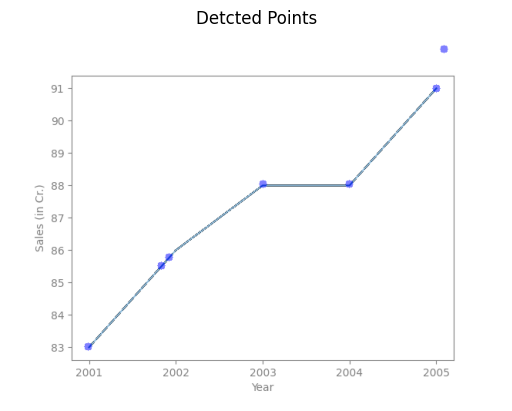

In [124]:
combined_image1 = overlay_images(prewittlines45, image)

# Display the result
plt.imshow(cv2.cvtColor(combined_image1, cv2.COLOR_BGR2RGB))
plt.title("Detcted Points")
plt.axis('off')
plt.show()

In [125]:
xAxisCord

426.0

In [126]:
toAdd

83.0

In [127]:
fromCal

411.5

In [128]:
x_labelsWithCent

[('2001', 102.5),
 ('2002', 216.0),
 ('2003', 329.0),
 ('2004', 441.0),
 ('2005', 554.0)]

In [129]:
# pointValues = []

# for point in final_points:
#     x1, y1  = point
    
#     finalVal = abs(y1 - fromCal)*vpp + toAdd
#     pointValues.append(finalVal)
    
# pointValues

In [130]:
# values

In [131]:
# mapped_values = []

# for indx in range(len(pointValues)):
#     mapped_values.append({xtitle: x_labels[indx], ytitle: pointValues[indx]})
            

# # Convert the list of dictionaries to a DataFrame
# final = pd.DataFrame(mapped_values)
# final

In [132]:
# final['actuals'] = values
# final

NEW SOL

In [133]:
# label_values = {label: None for label, _ in x_labelsWithCent}
# label_values

01

In [134]:
# for x1, y1 in merged_intersection_points:
#     finalVal = abs(y1 - fromCal) * vpp + toAdd
    
#     closest_label = min(x_labelsWithCent, key=lambda x: abs(x[1] - x1))[0]
    
#     label_values[closest_label] = finalVal
    
# label_values

In [135]:
def map_labels_to_points(labels, points):
    # Dictionary to store the result: label text -> y-coordinate from points
    label_to_y_coord = {}
    
    # List to store the points that are mapped to labels
    mapped_points = []

    # Iterate through each label
    for label, x_label in labels:
        # Initialize a variable to find the nearest point
        nearest_point = None
        nearest_point_coords = None  # to store the actual point coordinates (x, y)
        min_distance = float('inf')  # Start with infinity as the minimum distance
        
        # Compare the x-coordinate of the label with each point's x-coordinate
        for x_point, y_point in points:
            # Calculate the distance along the x-axis
            distance = abs(x_label - x_point)
            
            # Update nearest point if this point is closer
            if distance < min_distance:
                min_distance = distance
                nearest_point = y_point
                nearest_point_coords = (x_point, y_point)  # Store the full point
        
        # Map the label text to the y-coordinate of the nearest point
        label_to_y_coord[label] = nearest_point
        
        # Add the nearest point to the list of mapped points
        if nearest_point_coords not in mapped_points:
            mapped_points.append(nearest_point_coords)

    return label_to_y_coord, mapped_points

In [136]:
label_y_mapping, pointsToShow = map_labels_to_points(x_labelsWithCent, final_points)
label_y_mapping

{'2001': 409,
 '2002': 293.12698412698415,
 '2003': 198.0,
 '2004': 198.5,
 '2005': 74}

In [137]:
for i in label_y_mapping:
    finalVal = abs(label_y_mapping[i] - fromCal) * vpp + toAdd
    label_y_mapping[i] = finalVal
    
label_y_mapping

{'2001': 83.05952380952381,
 '2002': 85.81840513983371,
 '2003': 88.08333333333333,
 '2004': 88.07142857142857,
 '2005': 91.03571428571428}

In [138]:
x_labelsWithCent

[('2001', 102.5),
 ('2002', 216.0),
 ('2003', 329.0),
 ('2004', 441.0),
 ('2005', 554.0)]

<function matplotlib.pyplot.show(close=None, block=None)>

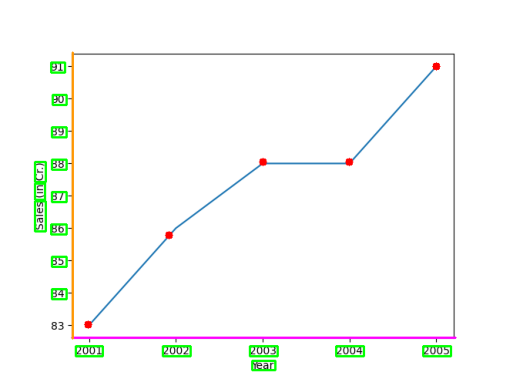

In [139]:
for point in pointsToShow:
    x, y = point
    cv2.circle(image1223, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.imshow(image1223)
plt.axis('off')
plt.show

02

In [140]:
# label_values = {label: None for label, _ in x_labelsWithCent}
# label_values

In [141]:
# final_points.sort(key=lambda x: x[0])
# final_points

In [142]:
# for x1, y1 in final_points:
#     finalVal = abs(y1 - fromCal) * vpp + toAdd
    
#     closest_label = min(x_labelsWithCent, key=lambda x: abs(x[1] - x1))[0]
    
#     label_values[closest_label] = finalVal
    
# label_values

In [143]:
# sorted_labels = sorted(x_labelsWithCent, key=lambda x: x[1])
# sorted_x_coords = [x[1] for x in sorted_labels]

In [144]:
# label_values = {label: None for label, _ in sorted_labels}
# label_values

In [145]:
# import bisect

# def find_closest_label(x1):
#     # Find the position where x1 would fit in the sorted list
#     pos = bisect.bisect_left(sorted_x_coords, x1)
    
#     # Check neighbors to find the closest actual label
#     if pos == 0:
#         return sorted_labels[0][0]
#     if pos == len(sorted_labels):
#         return sorted_labels[-1][0]
    
#     # Compare distances to the previous and the next label, if possible
#     before = sorted_labels[pos - 1]
#     after = sorted_labels[pos]
#     if abs(before[1] - x1) <= abs(after[1] - x1):
#         return before[0]
#     else:
#         return after[0]

In [146]:
# for x1, y1 in final_points:
#     finalVal = abs(y1 - fromCal) * vpp + toAdd
#     closest_label = find_closest_label(x1)
#     label_values[closest_label] = finalVal

In [147]:
# label_values

In [148]:
# values

In [149]:
final = pd.DataFrame(list(label_y_mapping.items()), columns=[xtitle, ytitle])
final

,year,sales in cry
0,2001,83.059524
1,2002,85.818405
2,2003,88.083333
3,2004,88.071429
4,2005,91.035714


In [150]:
data = pd.read_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Line\\Testing\\testData.csv')

In [151]:
column_data = data[str(ImageNumber)].dropna()
final['actuals'] = column_data
final

,year,sales in cry,actuals
0,2001,83.059524,83.0
1,2002,85.818405,86.0
2,2003,88.083333,88.0
3,2004,88.071429,88.0
4,2005,91.035714,91.0


In [152]:
toAdd

83.0

In [153]:
import sklearn.metrics
import math

mse = sklearn.metrics.mean_squared_error(final['actuals'], final[ytitle])
rmse = math.sqrt(mse)
rmse

0.09984164722588516

In [154]:
final['Error'] = None
final.at[0, 'Error'] = rmse

In [155]:
final.to_csv('c:\\College\\Sem 08\\Major Project\\Graphs\\Line\\Testing\\testImages\\' + f'{str(ImageNumber)}\\{str(ImageNumber)}.csv', index=False, sep=',', encoding='utf-8')

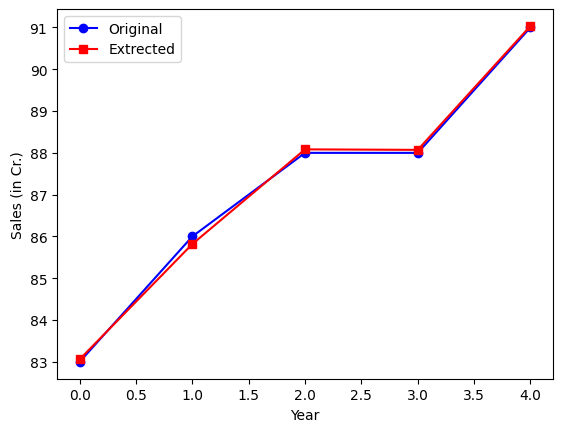

In [156]:
plt.plot(final['actuals'], marker='o', linestyle='-', color='blue', label='Original')
plt.plot(final['sales in cry'], marker='s', linestyle='-', color='red', label='Extrected')

plt.xlabel('Year')
plt.ylabel('Sales (in Cr.)')
plt.legend()
plt.show()